# ICL UCR — Baseline Comparison

**Experiment:** `random_k1_comparison_full` · random picking strategy · k=1 · 10 random seeds per dataset

## Dataset Coverage

We evaluate on **94 of the 128 UCR archive datasets**. The 34 excluded datasets fall into two categories:
- **Variable-length series** (11 datasets) — cannot be serialised into a fixed-length text prompt.
- **Context window exceeded** (23 datasets) — either too many classes (> 24) or the product `classes × series_length > 5,120`, which overflows the LLM context budget at k=1.

## Methods

| Model | Description |
|---|---|
| **Qwen3-4B** | Qwen3 4B text LLM; receives the time series as a serialised number sequence. |
| **Qwen3-4B (empty all TS)** | Same model with all time-series values zeroed out — ablation to isolate how much the model relies on the actual signal vs. prompt structure. |
| **ChatTS-8B** | ByteDance ChatTS 8B, a time-series specialist LLM fine-tuned on TS tasks. |
| **ChatTS-8B (empty all TS)** | ChatTS-8B with zeroed-out series — same ablation as above. |
| **Qwen3.6-27B** | Qwen3.6 27B text LLM; larger model, evaluated on a subset of datasets. |
| **Qwen3.6-27B (image TS)** | Qwen3.6 27B vision-language model receiving the time series as a **line plot image** (a chart a human would recognise). |
| **DINO-CLSA kNN** | Non-LLM baseline: 1-NN using DINOv2 embeddings of a **delay-embedded image** — the series is transformed into a 2D sliding-window matrix (not a line plot) and encoded with no language model. |
| **1-NN DTW** | Classic 1-nearest-neighbour with Dynamic Time Warping distance — strong traditional baseline. |
| **Random** | Random class assignment — lower-bound sanity check. |

Two **UCR reference** columns are shown but excluded from all model comparisons:
- **DTW (w=100):** best-known DTW result from the UCR archive leaderboard.
- **Default Rate:** balanced accuracy of always predicting the majority class (`1 / num_classes`).


In [3]:
import wandb
import pandas as pd
import numpy as np
import json
from pathlib import Path

if wandb.api.api_key is None:
    for folder in ["wandb_logger", "logger", ""]:
        token_path = Path(folder) / "token.txt"
        if token_path.exists():
            wandb.login(key=token_path.read_text().strip())
            break

ENTITY  = "aviramom-"
PROJECT = "multits"
EXP_ID  = "random_k1_comparison_full"

api = wandb.Api(timeout=60)
print(f"Connected to {ENTITY}/{PROJECT}")


Connected to aviramom-/multits


## 1 · Load Data from W&B

Runs are fetched from the W&B project and cached locally as a parquet file — set `FORCE_REFRESH = True` only when new runs have finished.

In [4]:
from tqdm.auto import tqdm

CONFIG_KEYS = ["task_id", "method", "num_samples", "exp_id", "input_mode", "num_shots", "random_seed", "picking_strategy"]
METRIC_KEYS = ["final_accuracy", "final_balanced_accuracy", "final_num_of_classes", "total_test_size",
               "flawed_count", "flawed_percentage"]

CACHE         = Path(f"cache_{EXP_ID}.parquet")
FORCE_REFRESH = False  # set True temporarily when new runs finish, then back to False

def get_val(cfg, summary, key):
    return summary.get(key, cfg.get(key))

if CACHE.exists() and not FORCE_REFRESH:
    df = pd.read_parquet(CACHE)
    print(f"Loaded {len(df)} rows from cache ({CACHE})")
else:
    all_runs = list(api.runs(path=f"{ENTITY}/{PROJECT}", per_page=1000))
    print(f"Total runs in project: {len(all_runs)}")

    rows = []
    for run in tqdm(all_runs, desc="Processing runs"):
        summary = {k: v for k, v in (run.summary or {}).items() if not k.startswith("_")}
        cfg     = run.config or {}
        row = {"run_id": run.id, "run_name": run.name, "state": run.state}
        for k in CONFIG_KEYS:
            row[k] = get_val(cfg, summary, k)
        for k in METRIC_KEYS:
            row[k] = get_val(cfg, summary, k)
        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty or "task_id" not in df.columns:
        raise RuntimeError(
            f"No runs matched EXP_ID='{EXP_ID}'. "
            f"Available exp_ids: {sorted({str(get_val(r.config or {}, {k:v for k,v in (r.summary or {}).items() if not k.startswith('_')}, 'exp_id')) for r in all_runs})}"
        )

    for col in METRIC_KEYS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df.to_parquet(CACHE)
    print(f"Cached {len(df)} rows → {CACHE}")

df["task"] = df["task_id"].str.replace("icl_ucr_", "", regex=False)
print(f"Runs for '{EXP_ID}' : {len(df)}")
print(f"Finished           : {(df['state'] == 'finished').sum()}")
print(f"Crashed/other      : {(df['state'] != 'finished').sum()}")
print(f"\nMethods:\n{df['method'].value_counts().to_string()}")
print(f"\nTasks:\n{df['task'].value_counts().to_string()}")


Loaded 6786 rows from cache (cache_random_k1_comparison_full.parquet)
Runs for 'random_k1_comparison_full' : 6786
Finished           : 6764
Crashed/other      : 22

Methods:
method
Qwen/Qwen3.6-27B-image-ts       764
Qwen/Qwen3.6-27B                760
Qwen/Qwen3-4B-Instruct-2507     752
knn_baseline                    752
bytedance-research/ChatTS-8B    752
empty_all_ts_chatts_baseline    752
empty_all_ts_baseline           752
dino_knn_clsa_baseline          752
random_baseline                 750

Tasks:
task
GunPointOldVersusYoung            74
Fish                              73
Yoga                              73
Crop                              73
ToeSegmentation2                  73
MiddlePhalanxOutlineAgeGroup      73
InsectEPGRegularTrain             73
ECG5000                           73
TwoPatterns                       73
CricketY                          73
ScreenType                        73
SonyAIBORobotSurface1             73
FordA                             73
G

In [5]:
# Assuming your DataFrame is named 'df'
df.to_csv('my_data.csv', index=False)

## 2 · Results

Balanced accuracy (average per-class recall) is used as the primary metric to account for class imbalance. For datasets evaluated with multiple seeds, the mean ± std across seeds is shown.

In [6]:
import re

METHOD_ORDER = [
    "bytedance-research/ChatTS-8B",
    "empty_all_ts_chatts_baseline",
    "Qwen/Qwen3-4B-Instruct-2507",
    "empty_all_ts_baseline",
    "Qwen/Qwen3.6-27B",
    "Qwen/Qwen3.6-27B-image-ts",
    "dino_knn_clsa_baseline",
    "knn_baseline",
    "random_baseline",
]
METHOD_LABELS = {
    "Qwen/Qwen3-4B-Instruct-2507"  : "Qwen3-4B",
    "empty_all_ts_baseline"        : "Qwen3-4B (empty all TS)",
    "bytedance-research/ChatTS-8B" : "ChatTS-8B",
    "empty_all_ts_chatts_baseline" : "ChatTS-8B (empty all TS)",
    "Qwen/Qwen3.6-27B"            : "Qwen3.6-27B",
    "Qwen/Qwen3.6-27B-image-ts"   : "Qwen3.6-27B (image TS)",
    "dino_knn_clsa_baseline"       : "DINO-CLSA kNN",
    "knn_baseline"                 : "1-NN DTW",
    "random_baseline"              : "Random",
}
REF_COLS = ["DTW (w=100)", "Default Rate"]

# ── Load UCR reference data ────────────────────────────────────────────────────
summary_raw = pd.read_csv("icl_data/DataSummary.csv")
summary_raw.columns = summary_raw.columns.str.strip()

def _parse_err(val):
    m = re.match(r"\s*([\d.]+)", str(val))
    return float(m.group(1)) if m else np.nan

summary_raw["DTW_acc"]         = 1.0 - summary_raw["DTW (w=100)"].apply(_parse_err)
summary_raw["default_acc"]     = 1.0 - summary_raw["Default rate"].astype(float)
summary_raw["num_classes"]     = pd.to_numeric(summary_raw["Class"], errors="coerce")
summary_raw["default_bal_acc"] = 1.0 / summary_raw["num_classes"]
ucr_ref = summary_raw.set_index("Name")[["DTW_acc", "default_acc", "default_bal_acc"]]

# ── Build pivot (rows=task, cols=method) ──────────────────────────────────────
finished        = df[df["state"] == "finished"].copy()
tasks           = sorted(finished["task"].unique())
methods_present = [m for m in METHOD_ORDER if m in finished["method"].unique()]

def build_table(metric, is_balanced=False):
    mean_p = finished.pivot_table(index="task", columns="method", values=metric, aggfunc="mean")
    std_p  = finished.pivot_table(index="task", columns="method", values=metric, aggfunc="std")

    cols = [m for m in methods_present if m in mean_p.columns]
    mean_p = mean_p[cols].reindex(tasks)
    std_p  = std_p.reindex(columns=cols).reindex(tasks)  # reindex so missing cols (std undefined for n=1) become NaN
    mean_p.columns = [METHOD_LABELS.get(c, c) for c in mean_p.columns]
    std_p.columns  = [METHOD_LABELS.get(c, c) for c in std_p.columns]

    mean_p["DTW (w=100)"]  = [ucr_ref.loc[t, "DTW_acc"]     if t in ucr_ref.index else np.nan for t in tasks]
    if is_balanced:
        mean_p["Default Rate"] = [ucr_ref.loc[t, "default_bal_acc"] if t in ucr_ref.index else np.nan for t in tasks]
    else:
        mean_p["Default Rate"] = [ucr_ref.loc[t, "default_acc"]     if t in ucr_ref.index else np.nan for t in tasks]

    macro = mean_p.mean(axis=0)
    macro.name = "Macro Avg"
    mean_p = pd.concat([mean_p, macro.to_frame().T])
    mean_p.index.name = "task"

    fmt = mean_p.copy().astype(object)
    for col in mean_p.columns:
        for idx in mean_p.index:
            m_val = mean_p.loc[idx, col]
            if col not in REF_COLS and idx != "Macro Avg" and col in std_p.columns:
                s_val = std_p.loc[idx, col] if idx in std_p.index else np.nan
                fmt.loc[idx, col] = f"{m_val:.3f} ± {s_val:.3f}" if pd.notna(m_val) else "—"
            else:
                fmt.loc[idx, col] = f"{m_val:.3f}" if pd.notna(m_val) else "—"

    fmt.index.name   = "Task"
    fmt.columns.name = ""
    return fmt, mean_p

if finished.empty:
    print("No finished runs yet — check squeue or job logs.")
else:
    fmt_bal, mean_bal = build_table("final_balanced_accuracy", is_balanced=True)

    print("BALANCED ACCURACY  (mean ± std over seeds, rows = tasks, cols = methods)")
    display(
        fmt_bal.style
        .set_caption(f"{EXP_ID} — Balanced Accuracy")
        .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
    )

BALANCED ACCURACY  (mean ± std over seeds, rows = tasks, cols = methods)


,ChatTS-8B,ChatTS-8B (empty all TS),Qwen3-4B,Qwen3-4B (empty all TS),Qwen3.6-27B,Qwen3.6-27B (image TS),DINO-CLSA kNN,1-NN DTW,Random,DTW (w=100),Default Rate
Task,,,,,,,,,,,
ArrowHead,0.339 ± 0.034,0.333 ± 0.000,0.330 ± 0.018,0.333 ± 0.000,0.319 ± 0.056,0.530 ± 0.133,0.457 ± 0.118,0.446 ± 0.116,0.331 ± 0.040,0.703,0.333
BME,0.645 ± 0.067,0.333 ± 0.000,0.418 ± 0.059,0.333 ± 0.000,0.577 ± 0.050,0.752 ± 0.106,0.625 ± 0.074,0.589 ± 0.097,0.344 ± 0.046,0.900,0.333
Beef,0.158 ± 0.061,0.200 ± 0.000,0.200 ± 0.018,0.200 ± 0.000,—,0.325 ± 0.039,0.375 ± 0.061,0.358 ± 0.089,0.175 ± 0.053,0.633,0.200
BeetleFly,0.519 ± 0.026,0.500 ± 0.000,0.500 ± 0.000,0.500 ± 0.000,0.463 ± 0.069,0.594 ± 0.118,0.625 ± 0.271,0.556 ± 0.201,0.512 ± 0.125,0.700,0.500
BirdChicken,0.562 ± 0.074,0.500 ± 0.000,0.506 ± 0.018,0.500 ± 0.000,0.569 ± 0.075,0.688 ± 0.088,0.706 ± 0.132,0.606 ± 0.135,0.512 ± 0.125,0.750,0.500
CBF,0.470 ± 0.098,0.333 ± 0.000,0.333 ± 0.000,0.333 ± 0.000,0.651 ± 0.110,0.950 ± 0.049,0.691 ± 0.118,0.790 ± 0.107,0.326 ± 0.024,0.997,0.333
Car,0.308 ± 0.101,0.250 ± 0.000,0.255 ± 0.058,0.250 ± 0.000,—,0.446 ± 0.090,0.419 ± 0.123,0.367 ± 0.122,0.223 ± 0.056,0.733,0.250
Chinatown,0.506 ± 0.012,0.500 ± 0.000,0.683 ± 0.103,0.500 ± 0.000,0.813 ± 0.080,0.812 ± 0.099,0.707 ± 0.055,0.765 ± 0.149,0.494 ± 0.044,0.956,0.500
ChlorineConcentration,0.337 ± 0.008,0.333 ± 0.000,0.332 ± 0.003,0.333 ± 0.000,0.367 ± 0.023,0.358 ± 0.028,0.331 ± 0.012,0.341 ± 0.016,0.348 ± 0.026,0.648,0.333


### Balanced Accuracy Heatmap

Red–green colour scale (0–1) for a quick visual overview; UCR reference columns shown separately.

In [7]:
if not finished.empty:
    tbl_no_macro = mean_bal.drop(index="Macro Avg", errors="ignore")
    model_part   = tbl_no_macro[[c for c in tbl_no_macro.columns if c not in REF_COLS]]
    ref_part     = tbl_no_macro[REF_COLS]

    styled = (
        model_part.style
        .background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)
        .format("{:.3f}", na_rep="—")
        .set_caption(f"{EXP_ID} — Balanced Accuracy heatmap")
    )
    display(styled)
    display(ref_part.style.format("{:.3f}", na_rep="—").set_caption("UCR reference — Balanced Accuracy"))

,ChatTS-8B,ChatTS-8B (empty all TS),Qwen3-4B,Qwen3-4B (empty all TS),Qwen3.6-27B,Qwen3.6-27B (image TS),DINO-CLSA kNN,1-NN DTW,Random
task,,,,,,,,,
ArrowHead,0.339,0.333,0.330,0.333,0.319,0.530,0.457,0.446,0.331
BME,0.645,0.333,0.418,0.333,0.577,0.752,0.625,0.589,0.344
Beef,0.158,0.200,0.200,0.200,—,0.325,0.375,0.358,0.175
BeetleFly,0.519,0.500,0.500,0.500,0.463,0.594,0.625,0.556,0.512
BirdChicken,0.562,0.500,0.506,0.500,0.569,0.688,0.706,0.606,0.512
CBF,0.470,0.333,0.333,0.333,0.651,0.950,0.691,0.790,0.326
Car,0.308,0.250,0.255,0.250,—,0.446,0.419,0.367,0.223
Chinatown,0.506,0.500,0.683,0.500,0.813,0.812,0.707,0.765,0.494
ChlorineConcentration,0.337,0.333,0.332,0.333,0.367,0.358,0.331,0.341,0.348


,DTW (w=100),Default Rate
task,,
ArrowHead,0.703,0.333
BME,0.900,0.333
Beef,0.633,0.200
BeetleFly,0.700,0.500
BirdChicken,0.750,0.500
CBF,0.997,0.333
Car,0.733,0.250
Chinatown,0.956,0.500
ChlorineConcentration,0.648,0.333


### Completed Runs per (Task, Method)

Shows how many finished runs exist per cell — target is 10 (one per seed). Incomplete cells may indicate failed or still-running jobs.

In [8]:
if not finished.empty:
    count_tbl = finished.pivot_table(
        index="task", columns="method", values="final_balanced_accuracy", aggfunc="count"
    ).fillna(0).astype(int)
    cols_c = [m for m in methods_present if m in count_tbl.columns]
    count_tbl = count_tbl[cols_c]
    count_tbl.columns = [METHOD_LABELS.get(c, c) for c in count_tbl.columns]
    count_tbl.index.name = "Task"
    display(
        count_tbl.style
        .background_gradient(cmap="YlGn", axis=None, vmin=0, vmax=10)
        .set_caption("Completed runs per (task, method) — target: 10")
    )

,ChatTS-8B,ChatTS-8B (empty all TS),Qwen3-4B,Qwen3-4B (empty all TS),Qwen3.6-27B,Qwen3.6-27B (image TS),DINO-CLSA kNN,1-NN DTW,Random
Task,,,,,,,,,
ArrowHead,8,8,8,8,8,8,8,8,8
BME,8,8,8,8,8,8,8,8,8
Beef,8,8,8,8,0,8,8,8,8
BeetleFly,8,8,8,8,8,8,8,8,8
BirdChicken,8,8,8,8,8,8,8,8,8
CBF,8,8,8,8,8,8,8,8,8
Car,8,8,8,8,0,8,8,8,8
Chinatown,8,8,8,8,8,8,8,8,8
ChlorineConcentration,8,8,8,8,8,8,8,8,8


### Per-Task Winner

The best-performing model on each dataset is highlighted in green.

In [9]:
if not finished.empty:
    def highlight_winner_row(row):
        """Green cell = best model method (reference cols excluded)."""
        styles = [""] * len(row)
        model_cols = [c for c in row.index if c not in REF_COLS]
        if not model_cols or row[model_cols].isna().all():
            return styles
        best_col = row[model_cols].idxmax()
        for i, col in enumerate(row.index):
            if col == best_col:
                styles[i] = "background-color: #4CAF50; color: white; font-weight: bold"
        return styles

    tbl_no_macro = mean_bal.drop(index="Macro Avg", errors="ignore")
    display(
        tbl_no_macro.style
        .apply(highlight_winner_row, axis=1)
        .format("{:.3f}", na_rep="—")
        .set_caption(f"{EXP_ID} — Balanced Accuracy: best model per task (green = winner)")
        .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
    )

,ChatTS-8B,ChatTS-8B (empty all TS),Qwen3-4B,Qwen3-4B (empty all TS),Qwen3.6-27B,Qwen3.6-27B (image TS),DINO-CLSA kNN,1-NN DTW,Random,DTW (w=100),Default Rate
task,,,,,,,,,,,
ArrowHead,0.339,0.333,0.330,0.333,0.319,0.530,0.457,0.446,0.331,0.703,0.333
BME,0.645,0.333,0.418,0.333,0.577,0.752,0.625,0.589,0.344,0.900,0.333
Beef,0.158,0.200,0.200,0.200,—,0.325,0.375,0.358,0.175,0.633,0.200
BeetleFly,0.519,0.500,0.500,0.500,0.463,0.594,0.625,0.556,0.512,0.700,0.500
BirdChicken,0.562,0.500,0.506,0.500,0.569,0.688,0.706,0.606,0.512,0.750,0.500
CBF,0.470,0.333,0.333,0.333,0.651,0.950,0.691,0.790,0.326,0.997,0.333
Car,0.308,0.250,0.255,0.250,—,0.446,0.419,0.367,0.223,0.733,0.250
Chinatown,0.506,0.500,0.683,0.500,0.813,0.812,0.707,0.765,0.494,0.956,0.500
ChlorineConcentration,0.337,0.333,0.332,0.333,0.367,0.358,0.331,0.341,0.348,0.648,0.333


### Win Count Summary

Number of datasets on which each model achieves the highest balanced accuracy.

In [10]:
if not finished.empty:
    tbl_no_macro = mean_bal.drop(index="Macro Avg", errors="ignore")
    model_cols = [c for c in tbl_no_macro.columns if c not in REF_COLS]

    winners = tbl_no_macro[model_cols].idxmax(axis=1)
    wins = winners.value_counts().reindex(model_cols, fill_value=0)
    wins.index.name = "Model"
    wins.name = "Datasets Won"

    total = len(tbl_no_macro)
    wins_pct = (wins / total * 100).round(1)

    summary = pd.DataFrame({"Datasets Won": wins, "Win %": wins_pct})
    summary = summary.sort_values("Datasets Won", ascending=False)

    print(f"Win counts — Balanced Accuracy  (out of {total} datasets)")
    display(
        summary.style
        .background_gradient(cmap="YlGn", subset=["Datasets Won"], axis=0)
        .format({"Datasets Won": "{:d}", "Win %": "{:.1f}%"})
        .set_caption(f"{EXP_ID} — # datasets each model wins on Balanced Accuracy")
        .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
    )

Win counts — Balanced Accuracy  (out of 94 datasets)


,Datasets Won,Win %
Model,,
Qwen3.6-27B (image TS),39,41.5%
1-NN DTW,24,25.5%
DINO-CLSA kNN,18,19.1%
Qwen3.6-27B,7,7.4%
Random,4,4.3%
ChatTS-8B,2,2.1%
Qwen3-4B (empty all TS),0,0.0%
ChatTS-8B (empty all TS),0,0.0%
Qwen3-4B,0,0.0%


## 3 · Statistical Analysis — Critical Difference Diagram

Following the methodology recommended by the UCR benchmark (Dau et al., 2019) and Demšar (2006):

1. Only datasets where **all** compared models have a result are included (complete-case analysis).
2. **Friedman test** checks whether any overall significant difference exists across all models.
3. **Pairwise Wilcoxon signed-rank tests** (not Nemenyi) compare every pair of models on their shared datasets.
4. **Holm correction** controls the family-wise error rate across all pairs.
5. Models are ranked per dataset (rank 1 = best); the **Critical Difference diagram** plots average ranks — lower rank (right side) is better. A thick bar connects models within which **no significant difference** was found (α = 0.05).


Datasets used: 64  (dropped 30 incomplete tasks)
Average ranks (higher = worse):
ChatTS-8B (empty all TS)    7.117188
Random                      7.039062
Qwen3-4B (empty all TS)     7.023438
Qwen3-4B                    6.164062
ChatTS-8B                   5.406250
Qwen3.6-27B                 3.507812
1-NN DTW                    3.195312
DINO-CLSA kNN               3.085938
Qwen3.6-27B (image TS)      2.460938
dtype: float64

Pairwise p-values (Wilcoxon + Holm):
  ✓  ChatTS-8B (empty all TS)  vs  DINO-CLSA kNN  — p=0.0000
  ✓  DINO-CLSA kNN  vs  Qwen3-4B (empty all TS)  — p=0.0000
  ✓  ChatTS-8B (empty all TS)  vs  Qwen3.6-27B (image TS)  — p=0.0000
  ✓  Qwen3-4B (empty all TS)  vs  Qwen3.6-27B (image TS)  — p=0.0000
  ✓  1-NN DTW  vs  ChatTS-8B (empty all TS)  — p=0.0000
  ✓  1-NN DTW  vs  Qwen3-4B (empty all TS)  — p=0.0000
  ✓  Qwen3.6-27B (image TS)  vs  Random  — p=0.0000
  ✓  1-NN DTW  vs  Random  — p=0.0000
  ✓  DINO-CLSA kNN  vs  Random  — p=0.0000
  ✓  ChatTS-8B  vs  Qwen3.6-2

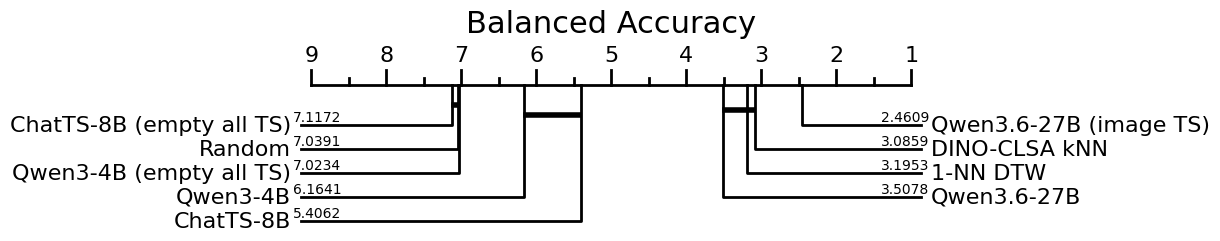

In [11]:
import operator
import math
import networkx
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, friedmanchisquare

_tbl = mean_bal.drop(index="Macro Avg", errors="ignore")
stat_model_cols = [c for c in _tbl.columns if c not in REF_COLS]
pivot_stat = _tbl[stat_model_cols].dropna()
print(f"Datasets used: {len(pivot_stat)}  (dropped {len(_tbl) - len(pivot_stat)} incomplete tasks)")

df_perf = (
    pivot_stat.reset_index()
    .melt(id_vars="task", var_name="classifier_name", value_name="accuracy")
    .rename(columns={"task": "dataset_name"})
)

def graph_ranks(avranks, names, p_values, cd=None, cdmethod=None, lowv=None, highv=None,
                width=6, textspace=1, reverse=False, filename=None, labels=False, **kwargs):
    width = float(width)
    textspace = float(textspace)

    def nth(l, n):
        n = lloc(l, n)
        return [a[n] for a in l]

    def lloc(l, n):
        if n < 0:
            return len(l[0]) + n
        else:
            return n

    sums = avranks
    nnames = names
    ssums = sums

    if lowv is None:
        lowv = min(1, int(math.floor(min(ssums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(ssums))))

    cline = 0.4
    k = len(sums)
    linesblank = 0
    scalewidth = width - 2 * textspace

    def rankpos(rank):
        if not reverse:
            a = rank - lowv
        else:
            a = highv - rank
        return textspace + scalewidth / (highv - lowv) * a

    distanceh = 0.25
    cline += distanceh
    minnotsignificant = max(2 * 0.2, linesblank)
    height = cline + ((k + 1) / 2) * 0.2 + minnotsignificant

    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()

    hf = 1. / height
    wf = 1. / width

    def hfl(l):
        return [a * hf for a in l]

    def wfl(l):
        return [a * wf for a in l]

    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(l, color='k', **kwargs):
        ax.plot(wfl(nth(l, 0)), hfl(nth(l, 1)), color=color, **kwargs)

    def text(x, y, s, *args, **kwargs):
        ax.text(wf * x, hf * y, s, *args, **kwargs)

    line([(textspace, cline), (width - textspace, cline)], linewidth=2)

    bigtick = 0.3
    smalltick = 0.15
    linewidth = 2.0
    linewidth_sign = 4.0

    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = smalltick
        if a == int(a):
            tick = bigtick
        line([(rankpos(a), cline - tick / 2), (rankpos(a), cline)], linewidth=2)

    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a), ha="center", va="bottom", size=16)

    k = len(ssums)
    space_between_names = 0.24

    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace - 0.1, chei)], linewidth=linewidth)
        if labels:
            text(textspace + 0.3, chei - 0.075, format(ssums[i], '.4f'), ha="right", va="center", size=10)
        text(textspace - 0.2, chei, nnames[i], ha="right", va="center", size=16)

    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace + scalewidth + 0.1, chei)], linewidth=linewidth)
        if labels:
            text(textspace + scalewidth - 0.3, chei - 0.075, format(ssums[i], '.4f'), ha="left", va="center", size=10)
        text(textspace + scalewidth + 0.2, chei, nnames[i], ha="left", va="center", size=16)

    cliques = form_cliques(p_values, nnames)
    start = cline + 0.2
    side = -0.02
    height = 0.1
    achieved_half = False

    for clq in cliques:
        if len(clq) == 1:
            continue
        min_idx = np.array(clq).min()
        max_idx = np.array(clq).max()
        if min_idx >= len(nnames) / 2 and not achieved_half:
            start = cline + 0.25
            achieved_half = True
        line([(rankpos(ssums[min_idx]) - side, start),
              (rankpos(ssums[max_idx]) + side, start)], linewidth=linewidth_sign)
        start += height


def form_cliques(p_values, nnames):
    m = len(nnames)
    g_data = np.zeros((m, m), dtype=np.int64)
    for p in p_values:
        if p[3] == False:
            i = np.where(nnames == p[0])[0][0]
            j = np.where(nnames == p[1])[0][0]
            min_i = min(i, j)
            max_j = max(i, j)
            g_data[min_i, max_j] = 1
    g = networkx.Graph(g_data)
    return networkx.find_cliques(g)


def wilcoxon_holm(alpha=0.05, df_perf=None):
    df_counts = pd.DataFrame({'count': df_perf.groupby(['classifier_name']).size()}).reset_index()
    max_nb_datasets = df_counts['count'].max()
    classifiers = list(df_counts.loc[df_counts['count'] == max_nb_datasets]['classifier_name'])
    friedman_p_value = friedmanchisquare(*(
        np.array(df_perf.loc[df_perf['classifier_name'] == c]['accuracy'])
        for c in classifiers))[1]
    if friedman_p_value >= alpha:
        print('The null hypothesis over the entire classifiers cannot be rejected')
        return [], pd.Series(dtype=float), 0
    m = len(classifiers)
    p_values = []
    for i in range(m - 1):
        classifier_1 = classifiers[i]
        perf_1 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_1]['accuracy'], dtype=np.float64)
        for j in range(i + 1, m):
            classifier_2 = classifiers[j]
            perf_2 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_2]['accuracy'], dtype=np.float64)
            p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
            p_values.append((classifier_1, classifier_2, p_value, False))
    k = len(p_values)
    p_values.sort(key=operator.itemgetter(2))
    for i in range(k):
        new_alpha = float(alpha / (k - i))
        if p_values[i][2] <= new_alpha:
            p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], True)
        else:
            break
    sorted_df_perf = df_perf.loc[df_perf['classifier_name'].isin(classifiers)].sort_values(['classifier_name', 'dataset_name'])
    rank_data = np.array(sorted_df_perf['accuracy']).reshape(m, max_nb_datasets)
    df_ranks = pd.DataFrame(data=rank_data, index=np.sort(classifiers),
                            columns=np.unique(sorted_df_perf['dataset_name']))
    average_ranks = df_ranks.rank(ascending=False).mean(axis=1).sort_values(ascending=False)
    return p_values, average_ranks, max_nb_datasets


def draw_cd_diagram(df_perf=None, alpha=0.05, title=None, labels=False):
    p_values, average_ranks, _ = wilcoxon_holm(df_perf=df_perf, alpha=alpha)
    print("Average ranks (higher = worse):")
    print(average_ranks)
    print("\nPairwise p-values (Wilcoxon + Holm):")
    for p in p_values:
        sig = "✓" if p[3] else "✗"
        print(f"  {sig}  {p[0]}  vs  {p[1]}  — p={p[2]:.4f}")
    graph_ranks(average_ranks.values, average_ranks.keys(), p_values,
                cd=None, reverse=True, width=9, textspace=1.5, labels=labels)
    font = {'family': 'sans-serif', 'color': 'black', 'weight': 'normal', 'size': 22}
    if title:
        plt.title(title, fontdict=font, y=0.9, x=0.5)
    plt.show()


draw_cd_diagram(df_perf=df_perf, alpha=0.05, title="Balanced Accuracy", labels=True)

## 4 · Reduced Comparison — Excluding Qwen3.6-27B (text)

The text-only `Qwen3.6-27B` was not evaluated on all 94 datasets, so including it in the full comparison forces us to drop any dataset where it has no result. Removing it from this second analysis retains more datasets and gives a broader statistical picture. `Qwen3.6-27B (image TS)` is kept.


In [21]:
EXCLUDE_27B_TEXT = {"Qwen/Qwen3.6-27B"}
methods_no27b  = [m for m in METHOD_ORDER if m not in EXCLUDE_27B_TEXT and m in finished["method"].unique()]
finished_no27b = finished[finished["method"].isin(methods_no27b)].copy()
tasks_no27b    = sorted(finished_no27b["task"].unique())

def build_table_no27b(metric, is_balanced=False):
    mean_p = finished_no27b.pivot_table(index="task", columns="method", values=metric, aggfunc="mean")
    std_p  = finished_no27b.pivot_table(index="task", columns="method", values=metric, aggfunc="std")
    cols   = [m for m in methods_no27b if m in mean_p.columns]
    mean_p = mean_p[cols].reindex(tasks_no27b)
    std_p  = std_p.reindex(columns=cols).reindex(tasks_no27b)
    mean_p.columns = [METHOD_LABELS.get(c, c) for c in mean_p.columns]
    std_p.columns  = [METHOD_LABELS.get(c, c) for c in std_p.columns]
    mean_p["DTW (w=100)"]  = [ucr_ref.loc[t, "DTW_acc"]         if t in ucr_ref.index else np.nan for t in tasks_no27b]
    mean_p["Default Rate"] = [ucr_ref.loc[t, "default_bal_acc"] if t in ucr_ref.index else np.nan for t in tasks_no27b] if is_balanced else [ucr_ref.loc[t, "default_acc"] if t in ucr_ref.index else np.nan for t in tasks_no27b]
    macro = mean_p.mean(axis=0)
    macro.name = "Macro Avg"
    mean_p = pd.concat([mean_p, macro.to_frame().T])
    mean_p.index.name = "task"
    fmt = mean_p.copy().astype(object)
    for col in mean_p.columns:
        for idx in mean_p.index:
            m_val = mean_p.loc[idx, col]
            if col not in REF_COLS and idx != "Macro Avg" and col in std_p.columns:
                s_val = std_p.loc[idx, col] if idx in std_p.index else np.nan
                fmt.loc[idx, col] = f"{m_val:.3f} ± {s_val:.3f}" if pd.notna(m_val) else "—"
            else:
                fmt.loc[idx, col] = f"{m_val:.3f}" if pd.notna(m_val) else "—"
    fmt.index.name   = "Task"
    fmt.columns.name = ""
    return fmt, mean_p

fmt_bal_no27b, mean_bal_no27b = build_table_no27b("final_balanced_accuracy", is_balanced=True)
print(f"Datasets in comparison (excl. text 27B): {len(tasks_no27b)}  (was {len(tasks)} with text 27B)")
print("BALANCED ACCURACY  (excl. Qwen3.6-27B text)")
display(
    fmt_bal_no27b.style
    .set_caption(f"{EXP_ID} — Balanced Accuracy (excl. Qwen3.6-27B text)")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)


Datasets in comparison (excl. text 27B): 94  (was 94 with text 27B)
BALANCED ACCURACY  (excl. Qwen3.6-27B text)


,ChatTS-8B,ChatTS-8B (empty all TS),Qwen3-4B,Qwen3-4B (empty all TS),Qwen3.6-27B (image TS),DINO-CLSA kNN,1-NN DTW,Random,DTW (w=100),Default Rate
Task,,,,,,,,,,
ArrowHead,0.339 ± 0.034,0.333 ± 0.000,0.330 ± 0.018,0.333 ± 0.000,0.530 ± 0.133,0.457 ± 0.118,0.446 ± 0.116,0.331 ± 0.040,0.703,0.333
BME,0.645 ± 0.067,0.333 ± 0.000,0.418 ± 0.059,0.333 ± 0.000,0.752 ± 0.106,0.625 ± 0.074,0.589 ± 0.097,0.344 ± 0.046,0.900,0.333
Beef,0.158 ± 0.061,0.200 ± 0.000,0.200 ± 0.018,0.200 ± 0.000,0.325 ± 0.039,0.375 ± 0.061,0.358 ± 0.089,0.175 ± 0.053,0.633,0.200
BeetleFly,0.519 ± 0.026,0.500 ± 0.000,0.500 ± 0.000,0.500 ± 0.000,0.594 ± 0.118,0.625 ± 0.271,0.556 ± 0.201,0.512 ± 0.125,0.700,0.500
BirdChicken,0.562 ± 0.074,0.500 ± 0.000,0.506 ± 0.018,0.500 ± 0.000,0.688 ± 0.088,0.706 ± 0.132,0.606 ± 0.135,0.512 ± 0.125,0.750,0.500
CBF,0.470 ± 0.098,0.333 ± 0.000,0.333 ± 0.000,0.333 ± 0.000,0.950 ± 0.049,0.691 ± 0.118,0.790 ± 0.107,0.326 ± 0.024,0.997,0.333
Car,0.308 ± 0.101,0.250 ± 0.000,0.255 ± 0.058,0.250 ± 0.000,0.446 ± 0.090,0.419 ± 0.123,0.367 ± 0.122,0.223 ± 0.056,0.733,0.250
Chinatown,0.506 ± 0.012,0.500 ± 0.000,0.683 ± 0.103,0.500 ± 0.000,0.812 ± 0.099,0.707 ± 0.055,0.765 ± 0.149,0.494 ± 0.044,0.956,0.500
ChlorineConcentration,0.337 ± 0.008,0.333 ± 0.000,0.332 ± 0.003,0.333 ± 0.000,0.358 ± 0.028,0.331 ± 0.012,0.341 ± 0.016,0.348 ± 0.026,0.648,0.333


### Balanced Accuracy Heatmap

In [22]:
tbl_no_macro_no27b = mean_bal_no27b.drop(index="Macro Avg", errors="ignore")
model_part_no27b   = tbl_no_macro_no27b[[c for c in tbl_no_macro_no27b.columns if c not in REF_COLS]]
ref_part_no27b     = tbl_no_macro_no27b[REF_COLS]
display(
    model_part_no27b.style
    .background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)
    .format("{:.3f}", na_rep="—")
    .set_caption(f"{EXP_ID} — Balanced Accuracy heatmap (excl. Qwen3.6-27B text)")
)
display(ref_part_no27b.style.format("{:.3f}", na_rep="—").set_caption("UCR reference — Balanced Accuracy"))


,ChatTS-8B,ChatTS-8B (empty all TS),Qwen3-4B,Qwen3-4B (empty all TS),Qwen3.6-27B (image TS),DINO-CLSA kNN,1-NN DTW,Random
task,,,,,,,,
ArrowHead,0.339,0.333,0.330,0.333,0.530,0.457,0.446,0.331
BME,0.645,0.333,0.418,0.333,0.752,0.625,0.589,0.344
Beef,0.158,0.200,0.200,0.200,0.325,0.375,0.358,0.175
BeetleFly,0.519,0.500,0.500,0.500,0.594,0.625,0.556,0.512
BirdChicken,0.562,0.500,0.506,0.500,0.688,0.706,0.606,0.512
CBF,0.470,0.333,0.333,0.333,0.950,0.691,0.790,0.326
Car,0.308,0.250,0.255,0.250,0.446,0.419,0.367,0.223
Chinatown,0.506,0.500,0.683,0.500,0.812,0.707,0.765,0.494
ChlorineConcentration,0.337,0.333,0.332,0.333,0.358,0.331,0.341,0.348


,DTW (w=100),Default Rate
task,,
ArrowHead,0.703,0.333
BME,0.900,0.333
Beef,0.633,0.200
BeetleFly,0.700,0.500
BirdChicken,0.750,0.500
CBF,0.997,0.333
Car,0.733,0.250
Chinatown,0.956,0.500
ChlorineConcentration,0.648,0.333


### Completed Runs per (Task, Method)

In [23]:
count_no27b = finished_no27b.pivot_table(
    index="task", columns="method", values="final_balanced_accuracy", aggfunc="count"
).fillna(0).astype(int)
cols_c = [m for m in methods_no27b if m in count_no27b.columns]
count_no27b = count_no27b[cols_c]
count_no27b.columns = [METHOD_LABELS.get(c, c) for c in count_no27b.columns]
count_no27b.index.name = "Task"
display(
    count_no27b.style
    .background_gradient(cmap="YlGn", axis=None, vmin=0, vmax=10)
    .set_caption("Completed runs per (task, method) — excl. Qwen3.6-27B text — target: 10")
)


,ChatTS-8B,ChatTS-8B (empty all TS),Qwen3-4B,Qwen3-4B (empty all TS),Qwen3.6-27B (image TS),DINO-CLSA kNN,1-NN DTW,Random
Task,,,,,,,,
ArrowHead,8,8,8,8,8,8,8,8
BME,8,8,8,8,8,8,8,8
Beef,8,8,8,8,8,8,8,8
BeetleFly,8,8,8,8,8,8,8,8
BirdChicken,8,8,8,8,8,8,8,8
CBF,8,8,8,8,8,8,8,8
Car,8,8,8,8,8,8,8,8
Chinatown,8,8,8,8,8,8,8,8
ChlorineConcentration,8,8,8,8,8,8,8,8


### Per-Task Winner

In [24]:
tbl_no_macro_no27b = mean_bal_no27b.drop(index="Macro Avg", errors="ignore")
display(
    tbl_no_macro_no27b.style
    .apply(highlight_winner_row, axis=1)
    .format("{:.3f}", na_rep="—")
    .set_caption(f"{EXP_ID} — Balanced Accuracy: best model per task (excl. Qwen3.6-27B text)")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)


,ChatTS-8B,ChatTS-8B (empty all TS),Qwen3-4B,Qwen3-4B (empty all TS),Qwen3.6-27B (image TS),DINO-CLSA kNN,1-NN DTW,Random,DTW (w=100),Default Rate
task,,,,,,,,,,
ArrowHead,0.339,0.333,0.330,0.333,0.530,0.457,0.446,0.331,0.703,0.333
BME,0.645,0.333,0.418,0.333,0.752,0.625,0.589,0.344,0.900,0.333
Beef,0.158,0.200,0.200,0.200,0.325,0.375,0.358,0.175,0.633,0.200
BeetleFly,0.519,0.500,0.500,0.500,0.594,0.625,0.556,0.512,0.700,0.500
BirdChicken,0.562,0.500,0.506,0.500,0.688,0.706,0.606,0.512,0.750,0.500
CBF,0.470,0.333,0.333,0.333,0.950,0.691,0.790,0.326,0.997,0.333
Car,0.308,0.250,0.255,0.250,0.446,0.419,0.367,0.223,0.733,0.250
Chinatown,0.506,0.500,0.683,0.500,0.812,0.707,0.765,0.494,0.956,0.500
ChlorineConcentration,0.337,0.333,0.332,0.333,0.358,0.331,0.341,0.348,0.648,0.333


### Win Count Summary

In [25]:
tbl_no_macro_no27b = mean_bal_no27b.drop(index="Macro Avg", errors="ignore")
model_cols_no27b   = [c for c in tbl_no_macro_no27b.columns if c not in REF_COLS]
winners_no27b      = tbl_no_macro_no27b[model_cols_no27b].idxmax(axis=1)
wins_no27b         = winners_no27b.value_counts().reindex(model_cols_no27b, fill_value=0)
wins_no27b.index.name = "Model"
wins_no27b.name       = "Datasets Won"
total_no27b    = len(tbl_no_macro_no27b)
wins_pct_no27b = (wins_no27b / total_no27b * 100).round(1)
summary_no27b  = pd.DataFrame({"Datasets Won": wins_no27b, "Win %": wins_pct_no27b}).sort_values("Datasets Won", ascending=False)
print(f"Win counts — Balanced Accuracy  (out of {total_no27b} datasets, excl. Qwen3.6-27B text)")
display(
    summary_no27b.style
    .background_gradient(cmap="YlGn", subset=["Datasets Won"], axis=0)
    .format({"Datasets Won": "{:d}", "Win %": "{:.1f}%"})
    .set_caption(f"{EXP_ID} — # datasets each model wins (excl. Qwen3.6-27B text)")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)


Win counts — Balanced Accuracy  (out of 94 datasets, excl. Qwen3.6-27B text)


,Datasets Won,Win %
Model,,
Qwen3.6-27B (image TS),43,45.7%
1-NN DTW,26,27.7%
DINO-CLSA kNN,18,19.1%
Random,5,5.3%
ChatTS-8B,2,2.1%
Qwen3-4B (empty all TS),0,0.0%
ChatTS-8B (empty all TS),0,0.0%
Qwen3-4B,0,0.0%


### Critical Difference Diagram

Datasets used: 94  (dropped 0 incomplete tasks)
Average ranks (higher = worse):
ChatTS-8B (empty all TS)    6.287234
Qwen3-4B (empty all TS)     6.212766
Random                      6.164894
Qwen3-4B                    5.308511
ChatTS-8B                   4.648936
DINO-CLSA kNN               2.664894
1-NN DTW                    2.622340
Qwen3.6-27B (image TS)      2.090426
dtype: float64

Pairwise p-values (Wilcoxon + Holm):
  ✓  ChatTS-8B (empty all TS)  vs  Qwen3.6-27B (image TS)  — p=0.0000
  ✓  Qwen3-4B (empty all TS)  vs  Qwen3.6-27B (image TS)  — p=0.0000
  ✓  ChatTS-8B (empty all TS)  vs  DINO-CLSA kNN  — p=0.0000
  ✓  DINO-CLSA kNN  vs  Qwen3-4B (empty all TS)  — p=0.0000
  ✓  1-NN DTW  vs  ChatTS-8B (empty all TS)  — p=0.0000
  ✓  1-NN DTW  vs  Qwen3-4B (empty all TS)  — p=0.0000
  ✓  Qwen3.6-27B (image TS)  vs  Random  — p=0.0000
  ✓  ChatTS-8B  vs  Qwen3.6-27B (image TS)  — p=0.0000
  ✓  DINO-CLSA kNN  vs  Random  — p=0.0000
  ✓  1-NN DTW  vs  Random  — p=0.0000
  ✓  DINO-CL

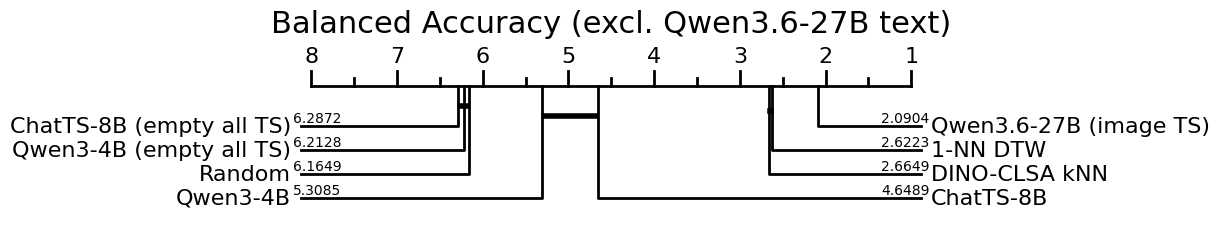

In [26]:
_tbl_no27b = mean_bal_no27b.drop(index="Macro Avg", errors="ignore")
stat_model_cols_no27b = [c for c in _tbl_no27b.columns if c not in REF_COLS]
pivot_stat_no27b = _tbl_no27b[stat_model_cols_no27b].dropna()
print(f"Datasets used: {len(pivot_stat_no27b)}  (dropped {len(_tbl_no27b) - len(pivot_stat_no27b)} incomplete tasks)")

df_perf_no27b = (
    pivot_stat_no27b.reset_index()
    .melt(id_vars="task", var_name="classifier_name", value_name="accuracy")
    .rename(columns={"task": "dataset_name"})
)

draw_cd_diagram(df_perf=df_perf_no27b, alpha=0.05, title="Balanced Accuracy (excl. Qwen3.6-27B text)", labels=True)


## 5 · Analysis Report

### Experiment Summary

- **Datasets:** 94 UCR archive datasets (128 total minus 34 excluded: 11 variable-length, 23 context-overflow)
- **Protocol:** k=1 in-context learning, random support-set picking, 8–10 seeds per (dataset, method) pair
- **Total finished runs:** 6,764 (22 crashed or still running)
- **Coverage gap:** Qwen3.6-27B (text) has runs on 64 of 94 datasets; the remaining 30 datasets have 0 finished runs for this model. All other 8 methods cover all 94 datasets.

---

### Macro Balanced Accuracy

Macro-averaged over all datasets on which each model was evaluated. The Qwen3.6-27B (text) figure is over its 64 available datasets; all other models are over all 94.

| Model | Macro Bal. Acc | # Datasets |
|---|:---:|:---:|
| **Qwen3.6-27B (image TS)** | **0.567** | 94 |
| Qwen3.6-27B (text) | 0.530 | 64 |
| DINO-CLSA kNN | 0.529 | 94 |
| 1-NN DTW | 0.527 | 94 |
| ChatTS-8B | 0.392 | 94 |
| Qwen3-4B | 0.373 | 94 |
| Random | 0.337 | 94 |
| Qwen3-4B (empty TS) | 0.336 | 94 |
| ChatTS-8B (empty TS) | 0.328 | 94 |
| *UCR DTW (w=100) — reference* | *0.774* | *—* |
| *Default Rate — reference* | *0.336* | *—* |

---

### Win Counts — 94 Datasets (excluding Qwen3.6-27B text)

A model wins a dataset if it achieves the highest mean balanced accuracy on that dataset.

| Model | Datasets Won | Win % |
|---|:---:|:---:|
| Qwen3.6-27B (image TS) | 43 | 45.7% |
| 1-NN DTW | 26 | 27.7% |
| DINO-CLSA kNN | 18 | 19.1% |
| Random | 5 | 5.3% |
| ChatTS-8B | 2 | 2.1% |
| Qwen3-4B | 0 | 0.0% |
| Qwen3-4B (empty TS) | 0 | 0.0% |
| ChatTS-8B (empty TS) | 0 | 0.0% |

On the 64 complete-case datasets where all 9 models have results: Qwen3.6-27B (image TS) 39 (41.5%), 1-NN DTW 24 (25.5%), DINO-CLSA kNN 18 (19.1%), Qwen3.6-27B (text) 7 (7.4%), Random 4 (4.3%), ChatTS-8B 2 (2.1%), all others 0.

---

### Statistical Analysis — Friedman + Wilcoxon-Holm (α=0.05)

#### 94 datasets — 8 models (excluding Qwen3.6-27B text)

Average rank across all 94 datasets (rank 1 = best):

| Model | Avg Rank |
|---|:---:|
| Qwen3.6-27B (image TS) | 2.09 |
| 1-NN DTW | 2.62 |
| DINO-CLSA kNN | 2.66 |
| ChatTS-8B | 4.65 |
| Qwen3-4B | 5.31 |
| Random | 6.16 |
| Qwen3-4B (empty TS) | 6.21 |
| ChatTS-8B (empty TS) | 6.29 |

Pairwise comparisons with **no significant difference** after Holm correction:

| Pair | p-value |
|---|:---:|
| 1-NN DTW vs DINO-CLSA kNN | 0.535 |
| Qwen3-4B (empty TS) vs Random | 0.713 |
| ChatTS-8B (empty TS) vs Random | 0.335 |
| ChatTS-8B (empty TS) vs Qwen3-4B (empty TS) | 0.098 |
| ChatTS-8B vs Qwen3-4B | 0.010 |

All remaining 23 of 28 pairwise comparisons are statistically significant.

#### 64 complete-case datasets — all 9 models

Average rank across the 64 datasets where every model has a result:

| Model | Avg Rank |
|---|:---:|
| Qwen3.6-27B (image TS) | 2.46 |
| DINO-CLSA kNN | 3.09 |
| 1-NN DTW | 3.20 |
| Qwen3.6-27B (text) | 3.51 |
| ChatTS-8B | 5.41 |
| Qwen3-4B | 6.16 |
| Qwen3-4B (empty TS) | 7.02 |
| Random | 7.04 |
| ChatTS-8B (empty TS) | 7.12 |

Pairwise comparisons with **no significant difference** after Holm correction (64-dataset analysis):

| Pair | p-value |
|---|:---:|
| 1-NN DTW vs DINO-CLSA kNN | 0.446 |
| DINO-CLSA kNN vs Qwen3.6-27B (text) | 0.041 |
| 1-NN DTW vs Qwen3.6-27B (text) | 0.218 |
| ChatTS-8B vs Qwen3-4B | 0.136 |
| ChatTS-8B (empty TS) vs Qwen3-4B (empty TS) | 0.171 |
| ChatTS-8B (empty TS) vs Random | 0.543 |
| Qwen3-4B (empty TS) vs Random | 0.894 |

## 6 · Critical Difference Diagram — All 9 Models

Complete-case analysis on the 64 datasets where every model has a result. This is the only comparison that includes Qwen3.6-27B (text).

In [ ]:
draw_cd_diagram(df_perf=df_perf, alpha=0.05, title="Balanced Accuracy — All 9 Models (64 complete-case datasets)", labels=True)